<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Distributed Machine Learning </b><br><br>Computer Assignment 3</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h1> Behzad jannati - CA3 -
        <h1> 810103098 _ Fall 2025 </h1>
        <h1> Dr. Mohammad Javad Dousti
    </div>
</div>

>[DMLS - Computer Assignment 3](#scrollTo=IDx51-eFWLrS)

>[Question 1: Video Game Sales Analysis with RDD](#scrollTo=B7fpVHHmWUvj)

>>[Section 1.1: Top 10 Best-Selling Games](#scrollTo=lu83lD9_WkTG)

>>[Section 1.2: Sales Analysis by Genre and Region](#scrollTo=LPWmoYeeWtxw)

>>[Section 1.3: Top Developers by Critic Score (Bonus: 10 points)](#scrollTo=hpNiMkXuW9lV)

>>[Additional code and visualization for Section 1.3](#scrollTo=znsaSaL-PXYq)



#DMLS - Computer Assignment 3

#Question 1: Video Game Sales Analysis with RDD

In [ ]:
# =============================================================================
# DMLS - Computer Assignment 3
# Question 1: Video Game Sales Analysis with Spark RDD
# =============================================================================

# -----------------------------------------------------------------------------
# Setup and Initialization
# -----------------------------------------------------------------------------

!pip install pyspark -q

from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np

# Initialize Spark Context
conf = SparkConf().setAppName("VideoGameSalesAnalysis").setMaster("local[*]")
sc = SparkContext.getOrCreate(conf)

# For reading the CSV file initially
spark = SparkSession.builder.getOrCreate()

print("Spark Context initialized successfully!")
print(f"Spark Version: {sc.version}")

Spark Context initialized successfully!
Spark Version: 4.0.1


In [ ]:
import csv
import io

# --------------------------------------------------
# Load the CSV file and create RDD
# --------------------------------------------------

# Uncomment the line below to upload file manually if needed
# uploaded = files.upload()

# Read the CSV file as text RDD
raw_rdd = sc.textFile("video_game_sales.csv")

# Extract the header row
header = raw_rdd.first()
print("Header columns:")
print(header)

# Remove the header from the data RDD
data_rdd = raw_rdd.filter(lambda line: line != header)

# Parse CSV lines into a structured format (Dictionary)
def parse_line(line):
    """
    Parses a CSV line properly handling commas inside quoted strings.
    Returns a dictionary with mapped fields or None if the line is malformed.
    """
    try:
        # Using csv.reader to handle edge cases (like "Game, The") correctly
        # io.StringIO turns the string line into a file-like object for the reader
        reader = csv.reader(io.StringIO(line))
        fields = next(reader)

        # Ensure the row has the expected number of columns (14 based on header)
        if len(fields) < 14:
            return None

        # Helper function to safely convert strings to float
        def safe_float(val):
            return float(val) if val and val.strip() != '' else 0.0

        # Mapping fields based on CSV structure:
        # 0:img, 1:title, 2:console, 3:genre, 4:publisher, 5:developer,
        # 6:critic_score, 7:total_sales, 8:na_sales, 9:jp_sales,
        # 10:pal_sales, 11:other_sales, 12:release_date, 13:last_update

        return {
            'title': fields[1].strip(),
            'console': fields[2].strip(),
            'genre': fields[3].strip(),
            'publisher': fields[4].strip(),
            'developer': fields[5].strip(),
            'critic_score': float(fields[6]) if fields[6].strip() else None,
            'total_sales': safe_float(fields[7]),
            'na_sales': safe_float(fields[8]),
            'jp_sales': safe_float(fields[9]),
            'pal_sales': safe_float(fields[10]),
            'other_sales': safe_float(fields[11]) if len(fields) > 11 else 0.0,
        }
    except Exception as e:
        # In case of parsing errors, return None to be filtered later
        return None

# Apply parsing and filter out invalid (None) records
parsed_rdd = data_rdd.map(parse_line).filter(lambda x: x is not None)

# Cache the RDD to optimize performance for subsequent actions
parsed_rdd.cache()

# Show sample parsed data
print("\nSample parsed data (first 3 records):")
for record in parsed_rdd.take(3):
    print(record)

# Display total valid records count
# With correct parsing, this count should be higher/more accurate than simple split(',')
print(f"\nTotal number of valid records: {parsed_rdd.count()}")

Header columns:
img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update

Sample parsed data (first 3 records):
{'title': 'Grand Theft Auto V', 'console': 'PS3', 'genre': 'Action', 'publisher': 'Rockstar Games', 'developer': 'Rockstar North', 'critic_score': 9.4, 'total_sales': 20.32, 'na_sales': 6.37, 'jp_sales': 0.99, 'pal_sales': 9.85, 'other_sales': 3.12}
{'title': 'Grand Theft Auto V', 'console': 'PS4', 'genre': 'Action', 'publisher': 'Rockstar Games', 'developer': 'Rockstar North', 'critic_score': 9.7, 'total_sales': 19.39, 'na_sales': 6.06, 'jp_sales': 0.6, 'pal_sales': 9.71, 'other_sales': 3.02}
{'title': 'Grand Theft Auto: Vice City', 'console': 'PS2', 'genre': 'Action', 'publisher': 'Rockstar Games', 'developer': 'Rockstar North', 'critic_score': 9.6, 'total_sales': 16.15, 'na_sales': 8.41, 'jp_sales': 0.47, 'pal_sales': 5.49, 'other_sales': 1.78}

Total number of valid records: 64016


##Section 1.1: Top 10 Best-Selling Games

🎮 TOP 10 BEST-SELLING VIDEO GAMES (by Total Sales)
Rank  Title                                        Total Sales (M)
------------------------------------------------------------
1     Grand Theft Auto V                           64.29          
2     Call of Duty: Black Ops                      30.99          
3     Call of Duty: Modern Warfare 3               30.71          
4     Call of Duty: Black Ops II                   29.59          
5     Call of Duty: Ghosts                         28.80          
6     Call of Duty: Black Ops 3                    26.72          
7     Call of Duty: Modern Warfare 2               25.02          
8     Minecraft                                    24.01          
9     Grand Theft Auto IV                          22.53          
10    Call of Duty: Advanced Warfare               21.78          


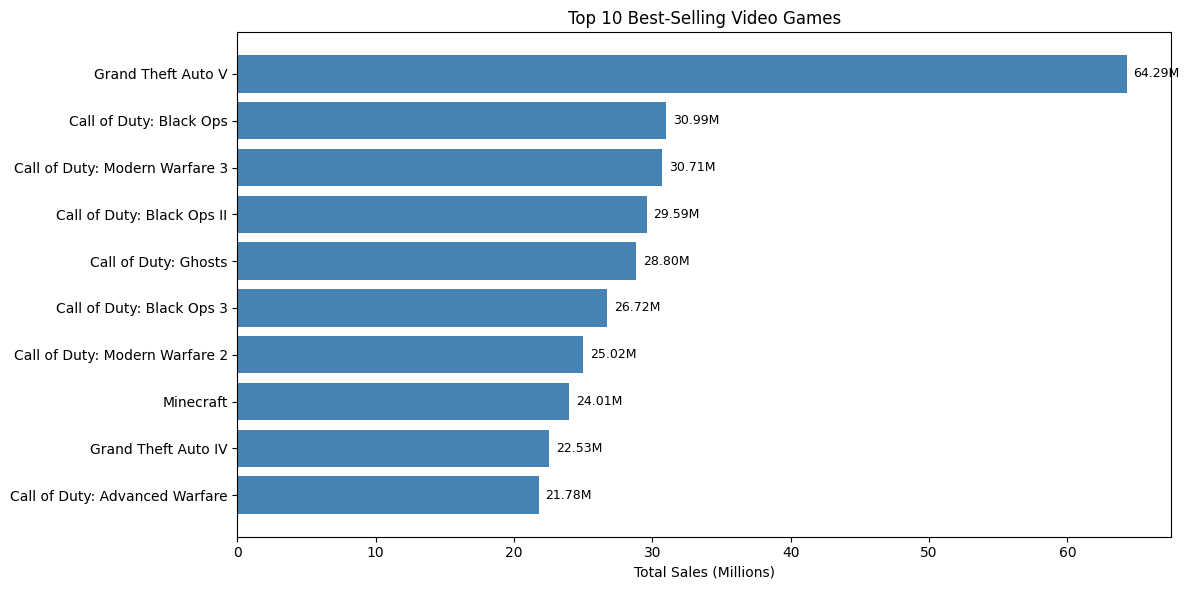

In [ ]:
# ============================================================
# Section 1.1: Top 10 Best-Selling Games by Total Sales
# ============================================================
# Task: For each game title, calculate the sum of total_sales
#       and display the top 10 games in descending order.
# ============================================================

# Step 1: Map each record to (title, total_sales) pair
title_sales_rdd = parsed_rdd.map(lambda x: (x['title'], x['total_sales']))

# Step 2: Reduce by key to sum total sales for each title
# (Some games appear multiple times for different consoles)
title_total_sales_rdd = title_sales_rdd.reduceByKey(lambda a, b: a + b)

# Step 3: Sort by total sales in descending order
sorted_sales_rdd = title_total_sales_rdd.sortBy(lambda x: x[1], ascending=False)

# Step 4: Take top 10 best-selling games
top_10_games = sorted_sales_rdd.take(10)

# Display results
print("=" * 60)
print("🎮 TOP 10 BEST-SELLING VIDEO GAMES (by Total Sales)")
print("=" * 60)
print(f"{'Rank':<6}{'Title':<45}{'Total Sales (M)':<15}")
print("-" * 60)

for rank, (title, sales) in enumerate(top_10_games, 1):
    print(f"{rank:<6}{title:<45}{sales:<15.2f}")

print("=" * 60)

# Visualization
titles = [game[0] for game in top_10_games]
sales = [game[1] for game in top_10_games]

plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(titles)), sales, color='steelblue')
plt.yticks(range(len(titles)), titles)
plt.xlabel('Total Sales (Millions)')
plt.title('Top 10 Best-Selling Video Games')
plt.gca().invert_yaxis()  # Highest at top

# Add value labels on bars
for bar, sale in zip(bars, sales):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{sale:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_10_games.png', dpi=150, bbox_inches='tight')
plt.show()

##Section 1.2: Sales Analysis by Genre and Region

📊 SALES ANALYSIS BY GENRE AND REGION (Ranked by Total Sales)
Rank  Genre               NA Sales (M)   JP Sales (M)   PAL Sales (M)  Total (M)      
-----------------------------------------------------------------------------------------------
1     Sports              607.47         109.27         341.92         1058.66        
2     Action              589.69         80.30          342.52         1012.51        
3     Shooter             528.27         33.99          324.74         887.00         
4     Misc                295.66         56.24          146.71         498.61         
5     Racing              269.72         20.23          179.14         469.09         
6     Role-Playing        171.67         130.56         91.02          393.25         
7     Platform            187.96         31.08          99.39          318.43         
8     Fighting            173.96         58.61          79.84          312.41         
9     Adventure           157.26         46.11          91.5

,Rank,Genre,NA_Sales (M),JP_Sales (M),PAL_Sales (M),Total_Sales (M)
0,1,Sports,607.47,109.27,341.92,1058.66
1,2,Action,589.69,80.30,342.52,1012.51
2,3,Shooter,528.27,33.99,324.74,887.00
3,4,Misc,295.66,56.24,146.71,498.61
4,5,Racing,269.72,20.23,179.14,469.09
5,6,Role-Playing,171.67,130.56,91.02,393.25
6,7,Platform,187.96,31.08,99.39,318.43
7,8,Fighting,173.96,58.61,79.84,312.41
8,9,Adventure,157.26,46.11,91.52,294.89
9,10,Simulation,152.84,35.98,86.86,275.68


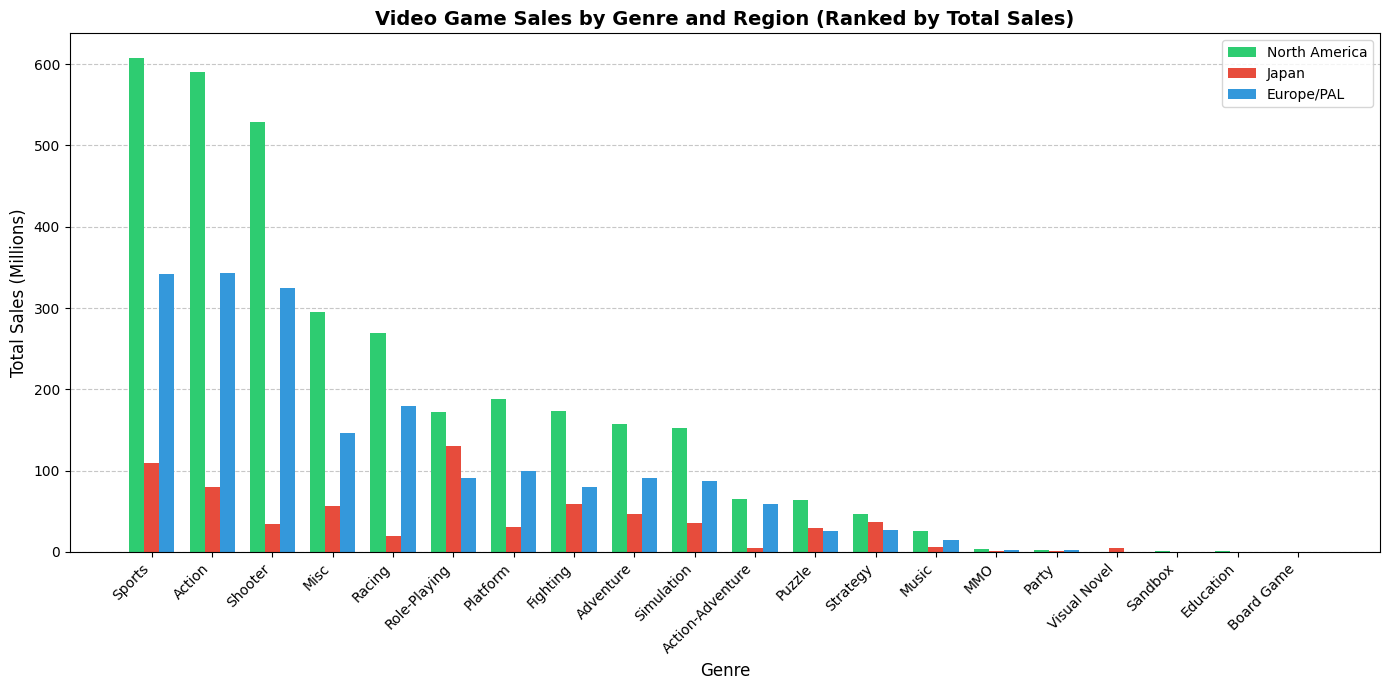

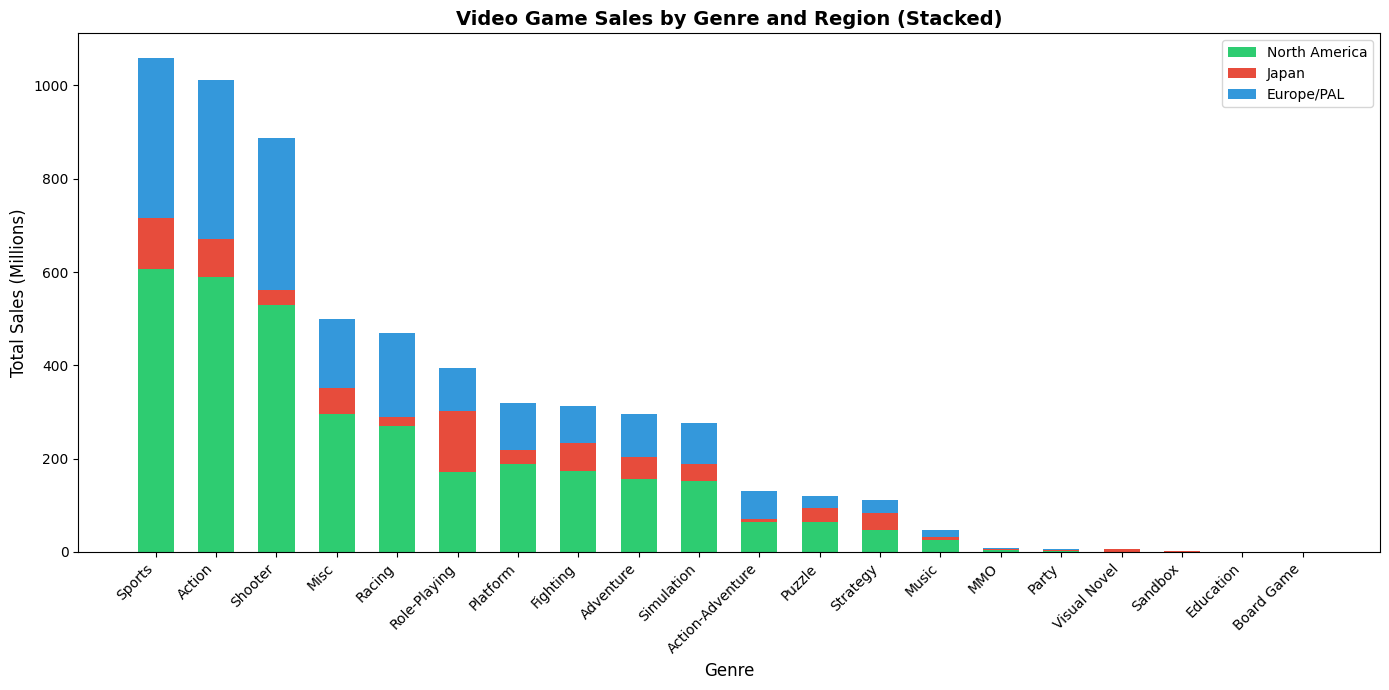

In [ ]:
# ============================================================
# Section 1.2: Sales Analysis by Genre and Region
# ============================================================
# Task: For each genre, calculate total sales in:
#       - North America (na_sales) - Index 8
#       - Japan (jp_sales) - Index 9
#       - Europe and Other Regions (pal_sales) - Index 10
# ============================================================

# Step 1: Map each record to (genre, (na_sales, jp_sales, pal_sales))
# Using correct indices: genre=3, na_sales=8, jp_sales=9, pal_sales=10
genre_region_rdd = parsed_rdd.map(lambda x: (
    x['genre'],
    (x['na_sales'], x['jp_sales'], x['pal_sales'])
)).filter(lambda x: x[0] is not None and x[0] != '')

# Step 2: Reduce by key to sum sales for each region within each genre
genre_totals_rdd = genre_region_rdd.reduceByKey(
    lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2])
)

# Step 3: Calculate the total sum of the 3 regions for sorting purposes
# Output format is now a tuple: (Genre, NA, JP, PAL, Calculated_Total)
genre_with_total_rdd = genre_totals_rdd.map(
    lambda x: (x[0], x[1][0], x[1][1], x[1][2], x[1][0] + x[1][1] + x[1][2])
)

# Step 4: Sort the RDD by the calculated total (index 4) in descending order
# THIS IS THE CORRECT, SCALABLE WAY TO SORT
sorted_genre_rdd = genre_with_total_rdd.sortBy(lambda x: x[4], ascending=False)

# Step 5: NOW collect the already sorted results to the driver for display
genre_sales_sorted = sorted_genre_rdd.collect()

# Display results as a formatted DataFrame-like table
print("=" * 95)
print("📊 SALES ANALYSIS BY GENRE AND REGION (Ranked by Total Sales)")
print("=" * 95)
print(f"{'Rank':<6}{'Genre':<20}{'NA Sales (M)':<15}{'JP Sales (M)':<15}{'PAL Sales (M)':<15}{'Total (M)':<15}")
print("-" * 95)

for rank, (genre, na, jp, pal, total) in enumerate(genre_sales_sorted, 1):
    print(f"{rank:<6}{genre:<20}{na:<15.2f}{jp:<15.2f}{pal:<15.2f}{total:<15.2f}")

print("=" * 95)

# Create DataFrame for better visualization
import pandas as pd

df_genre_sales = pd.DataFrame({
    'Rank': range(1, len(genre_sales_sorted) + 1),
    'Genre': [g[0] for g in genre_sales_sorted],
    'NA_Sales (M)': [round(g[1], 2) for g in genre_sales_sorted],
    'JP_Sales (M)': [round(g[2], 2) for g in genre_sales_sorted],
    'PAL_Sales (M)': [round(g[3], 2) for g in genre_sales_sorted],
    'Total_Sales (M)': [round(g[4], 2) for g in genre_sales_sorted]
})

print("\n📋 Genre Sales DataFrame:")
display(df_genre_sales)

# Visualization - Grouped Bar Chart
genres = [g[0] for g in genre_sales_sorted]
na_sales = [g[1] for g in genre_sales_sorted]
jp_sales = [g[2] for g in genre_sales_sorted]
pal_sales = [g[3] for g in genre_sales_sorted]

x = np.arange(len(genres))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width, na_sales, width, label='North America', color='#2ecc71')
bars2 = ax.bar(x, jp_sales, width, label='Japan', color='#e74c3c')
bars3 = ax.bar(x + width, pal_sales, width, label='Europe/PAL', color='#3498db')

ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Total Sales (Millions)', fontsize=12)
ax.set_title('Video Game Sales by Genre and Region (Ranked by Total Sales)', fontsize=14, fontweight='bold')

# Use set_xticks before set_xticklabels
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha='right')

ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('genre_region_sales.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional: Stacked Bar Chart
fig, ax = plt.subplots(figsize=(14, 7))

bottom_jp = np.array(na_sales)
bottom_pal = bottom_jp + np.array(jp_sales)

ax.bar(x, na_sales, width=0.6, label='North America', color='#2ecc71')
ax.bar(x, jp_sales, width=0.6, bottom=na_sales, label='Japan', color='#e74c3c')
ax.bar(x, pal_sales, width=0.6, bottom=bottom_pal.tolist(), label='Europe/PAL', color='#3498db')

ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Total Sales (Millions)', fontsize=12)
ax.set_title('Video Game Sales by Genre and Region (Stacked)', fontsize=14, fontweight='bold')

# FIXED: Use set_xticks before set_xticklabels
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha='right')

ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('genre_region_sales_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

##Section 1.3: Top Developers by Critic Score (Bonus: 10 points)

🏆 TOP 10 DEVELOPERS BY AVERAGE CRITIC SCORE
   (Minimum 10 Million Total Sales)
Rank  Developer                          Avg Critic Score    Total Sales (M)
--------------------------------------------------------------------------------
1     Rockstar Games                     9.80                13.94          
2     Naughty Dog                        9.08                20.14          
3     Rockstar North                     9.06                99.57          
4     Rocksteady Studios                 9.03                22.59          
5     Bungie                             8.90                13.38          
6     Turn 10 Studios                    8.90                12.12          
7     Rockstar San Diego                 8.72                22.27          
8     Dice                               8.63                17.32          
9     Harmonix Music Systems             8.54                29.33          
10    EA Digital Illusions CE            8.48                12.25   

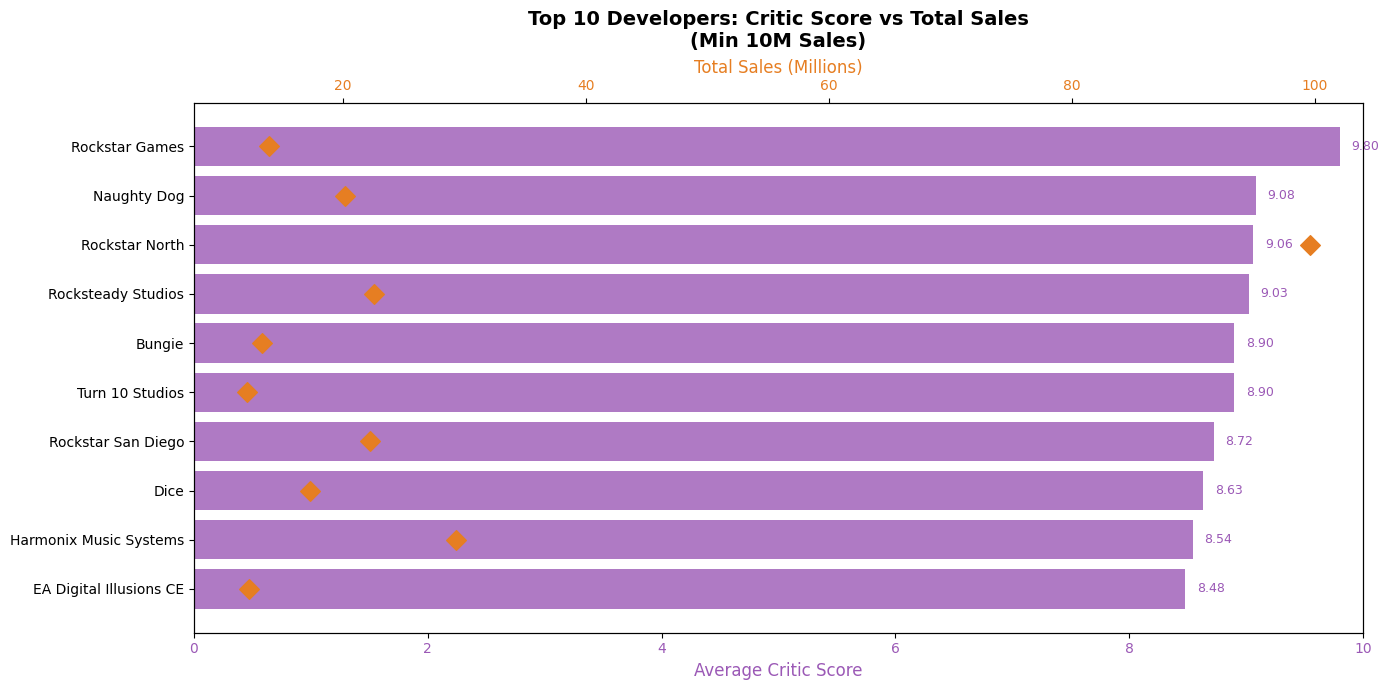

In [ ]:
# ============================================================
# Section 1.3: Top Developers by Average Critic Score
# ============================================================
# Task:
#   1. Filter records that have critic_score
#   2. For each developer, calculate:
#      - Average critic_score
#      - Sum of total_sales
#   3. Keep only developers with total_sales >= 10 million
#   4. Display top 10 developers by average critic score (descending)
# ============================================================

# Step 1: Filter records with valid critic_score and developer
filtered_rdd = parsed_rdd.filter(
    lambda x: x['critic_score'] is not None and x['developer'] is not None and x['developer'] != ''
)

# Step 2: Map to (developer, (critic_score, total_sales, count))
# We need count to calculate average later
developer_stats_rdd = filtered_rdd.map(
    lambda x: (x['developer'], (x['critic_score'], x['total_sales'], 1))
)

# Step 3: Reduce by key to aggregate statistics
# (sum_critic_score, sum_total_sales, count)
aggregated_rdd = developer_stats_rdd.reduceByKey(
    lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2])
)

# Step 4: Calculate average critic score and filter by total_sales >= 10M
developer_final_rdd = aggregated_rdd.map(
    lambda x: (x[0], x[1][0] / x[1][2], x[1][1])  # (developer, avg_score, total_sales)
).filter(
    lambda x: x[2] >= 10.0  # Filter: total_sales >= 10 million
)

# Step 5: Sort by average critic score in descending order
sorted_developers_rdd = developer_final_rdd.sortBy(lambda x: x[1], ascending=False)

# Step 6: Take top 10 developers
top_10_developers = sorted_developers_rdd.take(10)

# Display results
print("=" * 80)
print("🏆 TOP 10 DEVELOPERS BY AVERAGE CRITIC SCORE")
print("   (Minimum 10 Million Total Sales)")
print("=" * 80)
print(f"{'Rank':<6}{'Developer':<35}{'Avg Critic Score':<20}{'Total Sales (M)':<15}")
print("-" * 80)

for rank, (developer, avg_score, total_sales) in enumerate(top_10_developers, 1):
    print(f"{rank:<6}{developer:<35}{avg_score:<20.2f}{total_sales:<15.2f}")

print("=" * 80)

# Visualization
developers = [d[0] for d in top_10_developers]
avg_scores = [d[1] for d in top_10_developers]
total_sales = [d[2] for d in top_10_developers]

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart for average critic score
color1 = '#9b59b6'
bars = ax1.barh(range(len(developers)), avg_scores, color=color1, alpha=0.8)
ax1.set_yticks(range(len(developers)))
ax1.set_yticklabels(developers)
ax1.set_xlabel('Average Critic Score', color=color1, fontsize=12)
ax1.tick_params(axis='x', labelcolor=color1)
ax1.set_xlim(0, 10)

# Add value labels
for bar, score in zip(bars, avg_scores):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{score:.2f}', va='center', fontsize=9, color=color1)

# Secondary axis for total sales
ax2 = ax1.twiny()
color2 = '#e67e22'
ax2.scatter(total_sales, range(len(developers)), color=color2, s=100, marker='D', zorder=5)
ax2.set_xlabel('Total Sales (Millions)', color=color2, fontsize=12)
ax2.tick_params(axis='x', labelcolor=color2)

ax1.invert_yaxis()
ax1.set_title('Top 10 Developers: Critic Score vs Total Sales\n(Min 10M Sales)',
              fontsize=14, fontweight='bold', pad=40)

plt.tight_layout()
plt.savefig('top_developers.png', dpi=150, bbox_inches='tight')
plt.show()

## Additional code and visualization for Section 1.3

Section 1.3: Top 10 Developers by Average Critic Score
(Filtered: Total Sales >= 10 Million)
Rank  Developer                               Avg Critic Score  Total Sales (M)
-------------------------------------------------------------------------------------
1     Rockstar Games                          9.80              13.94          
2     Naughty Dog                             9.08              20.14          
3     Rockstar North                          9.06              99.57          
4     Rocksteady Studios                      9.03              22.59          
5     Bungie                                  8.90              13.38          
6     Turn 10 Studios                         8.90              12.12          
7     Rockstar San Diego                      8.72              22.27          
8     Dice                                    8.63              17.32          
9     Harmonix Music Systems                  8.54              29.33          
10    EA Digital Illu

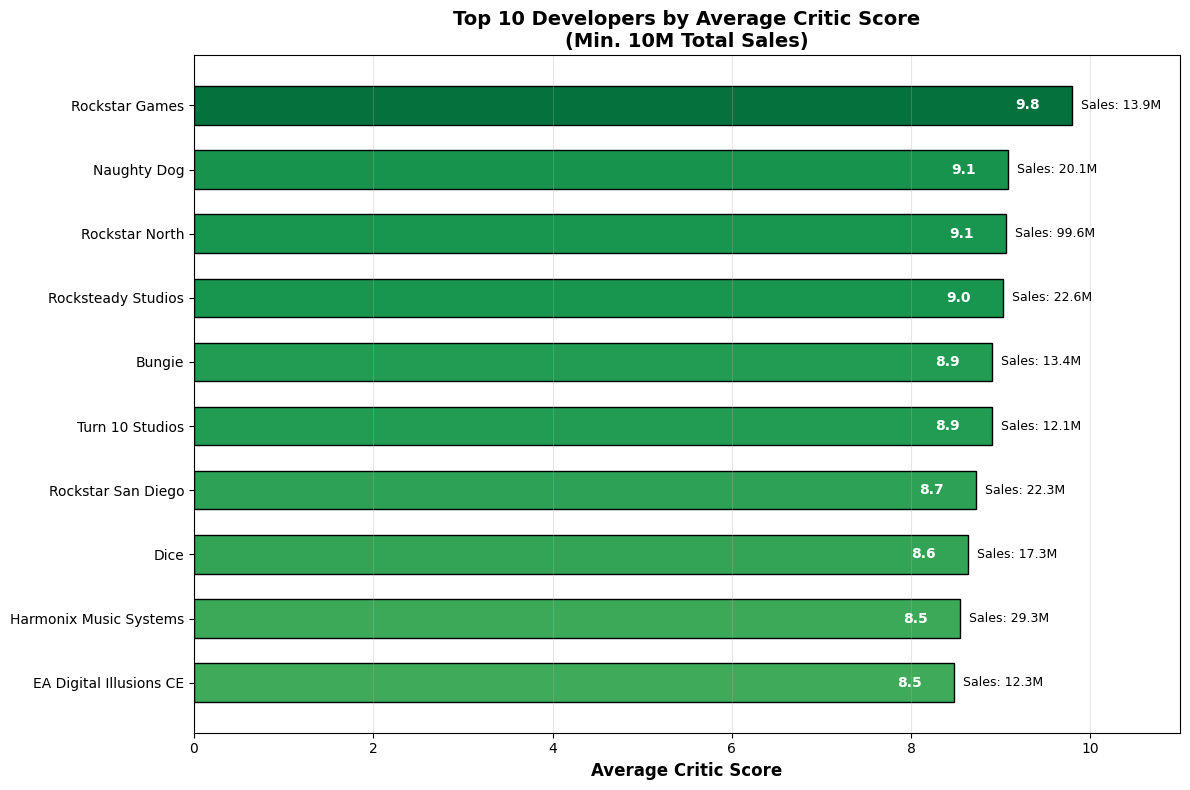


Chart saved as 'top_developers_critic_score.png'


In [ ]:
# -----------------------------------------------------------------------------
# Section 1.3: Top Developers by Critic Score (Bonus: 10 points)
# Task: Find developers with avg critic score, filtered by total sales >= 10M
# -----------------------------------------------------------------------------

def parse_developer_data(line):
    """
    Parse CSV line and extract developer, critic_score, and total_sales.
    Returns tuple: (developer, (critic_score, total_sales, count)) or None
    Only includes records with valid critic_score
    """
    try:
        fields = line.split(",")
        # developer at index 5, critic_score at index 6, total_sales at index 6
        # Wait - need to check actual column positions from the data

        # Based on the CSV structure shown:
        # img(0), title(1), console(2), genre(3), publisher(4), developer(5),
        # critic_score(6), total_sales(7), na_sales(8), jp_sales(9), pal_sales(10),
        # other_sales(11), release_date(12), last_update(13)

        developer = fields[5].strip() if len(fields) > 5 else None
        critic_score_str = fields[6].strip() if len(fields) > 6 else ""
        total_sales_str = fields[7].strip() if len(fields) > 7 else ""

        # Only process records with valid critic_score
        if not critic_score_str or critic_score_str == "":
            return None

        critic_score = float(critic_score_str)
        total_sales = float(total_sales_str) if total_sales_str else 0.0

        if developer:
            # Return (developer, (sum_critic_score, total_sales, count))
            return (developer, (critic_score, total_sales, 1))
        return None
    except (ValueError, IndexError):
        return None

# Parse and filter data (only records with valid critic_score)
developer_rdd = data_rdd.map(parse_developer_data).filter(lambda x: x is not None)

# Aggregate by developer
# Combine: (sum_scores, sum_sales, count)
developer_aggregated = developer_rdd.reduceByKey(
    lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2])
)

# Calculate average critic score and filter by total sales >= 10 million
def calculate_avg_and_filter(record):
    """
    Calculate average critic score and check if total sales >= 10M
    Returns: (developer, avg_critic_score, total_sales) or None
    """
    developer, (sum_scores, total_sales, count) = record
    avg_score = sum_scores / count if count > 0 else 0

    # Filter: only keep developers with total sales >= 10 million
    if total_sales >= 10.0:
        return (developer, avg_score, total_sales)
    return None

# Apply filter and remove None values
filtered_developers = developer_aggregated.map(calculate_avg_and_filter).filter(lambda x: x is not None)

# Sort by average critic score in descending order and take top 10
top_10_developers = filtered_developers.sortBy(lambda x: x[1], ascending=False).take(10)

# Display results
print("=" * 85)
print("Section 1.3: Top 10 Developers by Average Critic Score")
print("(Filtered: Total Sales >= 10 Million)")
print("=" * 85)
print(f"{'Rank':<6}{'Developer':<40}{'Avg Critic Score':<18}{'Total Sales (M)':<15}")
print("-" * 85)

for rank, (developer, avg_score, total_sales) in enumerate(top_10_developers, 1):
    print(f"{rank:<6}{developer[:38]:<40}{avg_score:<18.2f}{total_sales:<15.2f}")

print("=" * 85)

# Create visualization for top developers
fig, ax = plt.subplots(figsize=(12, 8))

developers = [item[0][:25] + '...' if len(item[0]) > 25 else item[0] for item in top_10_developers]
avg_scores = [item[1] for item in top_10_developers]
total_sales_dev = [item[2] for item in top_10_developers]

# Create horizontal bar chart
y_pos = np.arange(len(developers))
colors = plt.cm.RdYlGn(np.array(avg_scores) / 10)  # Color based on score

bars = ax.barh(y_pos, avg_scores, color=colors, edgecolor='black', height=0.6)

# Add total sales as text annotations
for i, (score, sales) in enumerate(zip(avg_scores, total_sales_dev)):
    ax.text(score + 0.1, i, f'Sales: {sales:.1f}M', va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(developers, fontsize=10)
ax.invert_yaxis()  # Top developer at the top
ax.set_xlabel('Average Critic Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Developers by Average Critic Score\n(Min. 10M Total Sales)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 11)
ax.grid(axis='x', alpha=0.3)

# Add score labels on bars
for bar, score in zip(bars, avg_scores):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('top_developers_critic_score.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChart saved as 'top_developers_critic_score.png'")

In [ ]:
# -----------------------------------------------------------------------------
# Cleanup: Stop Spark Context
# -----------------------------------------------------------------------------

# Stop Spark Context when done
sc.stop()
print("\nSpark Context stopped successfully!")
print("Question 1 completed!")


Spark Context stopped successfully!
Question 1 completed!
